<div style="display: flex; justify-content: space-between;">
<div style="text-align: left; display: inline-block;" align="left"><b>Tepper School of Business </b></div>
<div style="text-align: right; display: inline-block;" align="right"><i>Copyright Dennis Epple</i></div>
</div>
<hr>
<div style="display: flex; justify-content: space-between;">
<div style="text-align: left" align="left">Statistical Decision Making (45-752)</div>
</div>

In [1]:
%precision %.4f
import tprstats
import pandas
import numpy
from scipy import stats
import matplotlib.pyplot as plt
from scipy.stats import norm, t, uniform

# Stat Mini4 Script Slide Set 8
## Regression with Indicator Variables and Interactions


Import Water_Conservation_Data.xlsx

In [2]:
Water_Conservation_Data = pandas.read_excel("Water_Conservation_Data.xlsx")

In [3]:
# find median water use in 2006
Water_Conservation_Data["WATER_2006"].median()

46.0000

This tells us that median water use in 2006 was 46 thousand gallons.  

Next, we create an indicator called High. High equals 1 for above-median water users in 2006 and 0 for below-median water users in in 2006. Then add High to the water data.

In [4]:
Water_Conservation_Data["High"] = numpy.where(Water_Conservation_Data["WATER_2006"] >= 46, 1, 0)

The following command selects the data for high users and calculates the variance of water use in summer 2007 for high users.

In [5]:
High_Users=Water_Conservation_Data[Water_Conservation_Data['High'] == 1]
var_High07 = High_Users['SUMMER_07'].var()
var_High07

1166.1570

The following command selects the data for low users and calculates the variance of water use in summer 2007 for low users.

In [6]:
Low_Users=Water_Conservation_Data[Water_Conservation_Data['High'] == 0]
var_Low07 = Low_Users['SUMMER_07'].var()
var_Low07

141.5177

We see that the standard deviation of water use in summer 2007 is greater for high users (1166) than for low users (142). This is heteroskedasticity. 

In [7]:
# Select the subset of observations in the control group and treatment group 3
WatDat34 = Water_Conservation_Data.query("GROUP==3 | GROUP==4")

Estimate model including product of High and TREAT3. The product of two variables is called an *interaction*.  

To add an interaction to a formula, write `I(High*TREAT3)` as shown below'

In [8]:
RegH_T3 = tprstats.model("cs", "SUMMER_07 ~ High + TREAT3 + I(High*TREAT3)", WatDat34)
RegH_T3.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:              SUMMER_07   R-squared:                       0.217
Model:                            OLS   Adj. R-squared:                  0.217
No. Observations:               83319   F-statistic:                     7836.
Covariance Type:                  HC1   Prob (F-statistic):               0.00
====================================================================================
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept           22.7555      0.063    362.179      0.000      22.632      22.879
High                27.1720      0.192    141.436      0.000      26.795      27.548
TREAT3              -0.5934      0.157     -3.771      0.000      -0.902      -0.285
I(High * TREAT3)    -2.1150      0.466     -4.540      0.000      -3.028      -1.202
====================================================================================

Notes:
[1] Standard Errors are heteroscedasticity robust (HC1)
"""

The following command estimates the model for all treatments with interactions between high and low for all treatments.

In [9]:
RegH_All = tprstats.model("cs", "SUMMER_07 ~ High + TREAT1 + TREAT2 + TREAT3 + I(High*TREAT1) + I(High*TREAT2) + I(High*TREAT3)", Water_Conservation_Data)
RegH_All.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:              SUMMER_07   R-squared:                       0.216
Model:                            OLS   Adj. R-squared:                  0.216
No. Observations:              106669   F-statistic:                     4255.
Covariance Type:                  HC1   Prob (F-statistic):               0.00
====================================================================================
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept           22.7555      0.063    362.174      0.000      22.632      22.879
High                27.1720      0.192    141.434      0.000      26.795      27.548
TREAT1              -0.2702      0.170     -1.592      0.111      -0.603       0.062
TREAT2              -0.4265      0.181     -2.352      0.019      -0.782      -0.071
TREAT3              -0.5934      0.157     -3.771      0.000      -0.902      -0.285
I(High * TREAT1)     0.2598      0.534      0.487      0.627      -0.787       1.307
I(High * TREAT2)    -0.9009      0.500     -1.802      0.071      -1.881       0.079
I(High * TREAT3)    -2.1150      0.466     -4.540      0.000      -3.028      -1.202
====================================================================================

Notes:
[1] Standard Errors are heteroscedasticity robust (HC1)
"""

Test the  hypothesis that difference in treatment effects between high and low users was the same for treatment 1 and treatment 2.

In [10]:
# coefTestH(RegH_All,c("High:TREAT1=High:TREAT2"))a
RegH_All.wald_test("I(High * TREAT1) = I(High * TREAT2)")

p-value:  0.0874


In [11]:
# Model with only main effects
RegMain = tprstats.model("cs", "SUMMER_07 ~ High + TREAT1 + TREAT2 + TREAT3 + High", Water_Conservation_Data)
RegMain.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:              SUMMER_07   R-squared:                       0.216
Model:                            OLS   Adj. R-squared:                  0.216
No. Observations:              106669   F-statistic:                     7429.
Covariance Type:                  HC1   Prob (F-statistic):               0.00
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     22.9078      0.075    305.782      0.000      22.761      23.055
High          26.8703      0.156    172.244      0.000      26.565      27.176
TREAT1        -0.1386      0.269     -0.515      0.607      -0.667       0.389
TREAT2        -0.8776      0.250     -3.514      0.000      -1.367      -0.388
TREAT3        -1.6645      0.235     -7.071      0.000      -2.126      -1.203
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity robust (HC1)
"""

## Binary Choice Models
### Analyze Bottle Recycling

In [12]:
# Calculate p-value for AirBnB
2 * t.cdf(-3.5, 6233)

0.0005

In [13]:
# Import Bottle_Recycling_Data.xlsx
Bottle_Recycling_Data = pandas.read_excel("Bottle_Recycling_Data.xlsx")

In [14]:
# Linear Probability Model
RecylReg = tprstats.model("cs", "Recycler~Income+Midwest+Northeast+West+Them+Me+Green+Goallaw+Planlaw+Mandrecylaw+Nonwaterdep+Waterdep", Bottle_Recycling_Data)
RecylReg.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:               Recycler   R-squared:                       0.221
Model:                            OLS   Adj. R-squared:                  0.205
No. Observations:                 608   F-statistic:                     17.18
Covariance Type:                  HC1   Prob (F-statistic):           8.88e-32
===============================================================================
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept       0.3452      0.057      6.013      0.000       0.232       0.458
Income          0.0111      0.004      2.966      0.003       0.004       0.018
Midwest         0.0609      0.048      1.270      0.204      -0.033       0.155
Northeast       0.2308      0.059      3.912      0.000       0.115       0.347
West            0.0799      0.065      1.228      0.220      -0.048       0.208
Them            0.0010      0.039      0.026      0.979      -0.075       0.077
Me              0.1548      0.035      4.377      0.000       0.085       0.224
Green           0.1267      0.034      3.673      0.000       0.059       0.194
Goallaw        -0.0671      0.122     -0.549      0.584      -0.307       0.173
Planlaw         0.1043      0.055      1.882      0.060      -0.005       0.213
Mandrecylaw     0.1780      0.055      3.259      0.001       0.071       0.285
Nonwaterdep    -0.0045      0.057     -0.078      0.938      -0.117       0.108
Waterdep        0.1560      0.058      2.694      0.007       0.042       0.270
===============================================================================

Notes:
[1] Standard Errors are heteroscedasticity robust (HC1)
"""

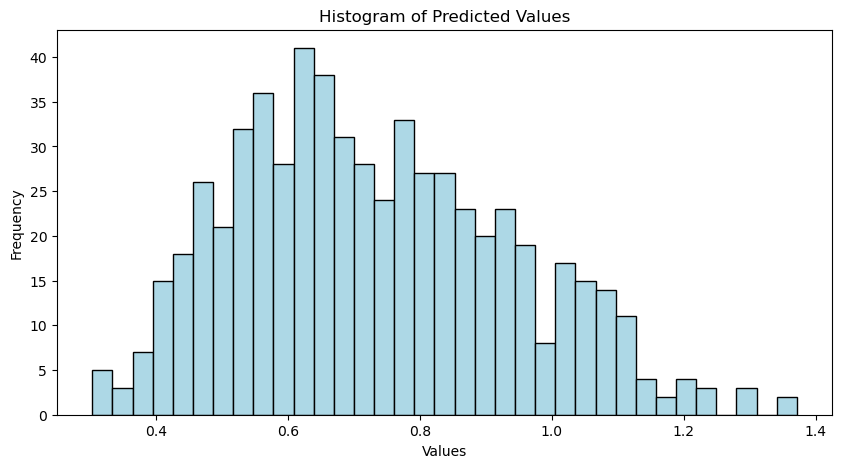

In [15]:
# Calculate fitted values
RecylPred=RecylReg.predict()
# Set plot dimensions
fig, ax = plt.subplots(figsize=(10, 5))
# Plot the histogram
ax.hist(RecylPred, bins=35, edgecolor='black', color='lightblue')
# Add titles and labels
ax.set_title('Histogram of Predicted Values')
ax.set_xlabel('Values')
ax.set_ylabel('Frequency')

# Show the plot
plt.show()

The commands below plot the logit function shown in the slides. You do not need to learn how to do this plot.

In [16]:
def abline(intercept, slope):
    axes = plt.gca()
    x_vals = numpy.array(axes.get_xlim())
    y_vals = intercept + slope * x_vals
    plt.plot(x_vals, y_vals, "--")

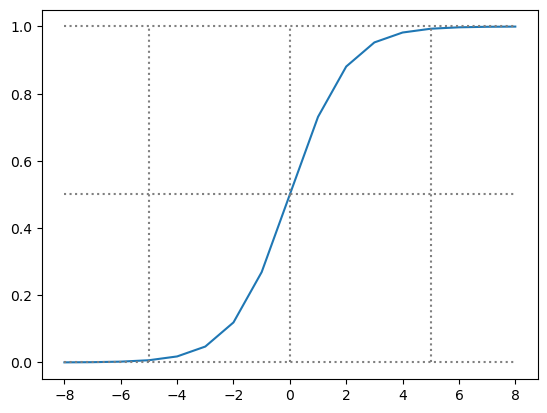

In [17]:
# Create variable x with integers from -8 to 8
x = numpy.array(range(-8, 9))

# Calculate logit probability with beta0=0 and beta1=1
beta0 = 0
beta1 = 1

y = numpy.exp(beta0 + beta1 * x) / (1 + numpy.exp(beta0 + beta1 * x))
plt.plot(x, y)
plt.vlines(x=[-5, 0, 5], ymin=0, ymax=1, color="grey", linestyles="dotted")
plt.hlines(y=[0, 0.5, 1], xmin=-8, xmax=8, color="grey", linestyles="dotted")

You might want to experiment above with other values of beta0 and beta1.

### Logit model for bottle recycling

In [18]:
RecylLogit = tprstats.model("logit", "Recycler~Income+Midwest+Northeast+West+Them+Me+Green+Goallaw+Planlaw+Mandrecylaw+Nonwaterdep+Waterdep", 
                            Bottle_Recycling_Data)
RecylLogit.summary()

Optimization terminated successfully.
         Current function value: 0.439843
         Iterations 7


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:               Recycler   No. Observations:                  608
Model:                          Logit   Df Residuals:                      595
Method:                           MLE   Df Model:                           12
Date:                Mon, 14 Apr 2025   Pseudo R-squ.:                  0.2455
Time:                        16:20:43   Log-Likelihood:                -267.42
converged:                       True   LL-Null:                       -354.46
Covariance Type:            nonrobust   LLR p-value:                 6.997e-31
===============================================================================
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept      -1.1695      0.320     -3.656      0.000      -1.796      -0.542
Income          0.0921      0.028      3.267      0.001       0.037       0.147
Midwest         0.3842      0.258      1.488      0.137      -0.122       0.890
Northeast       2.4227      0.600      4.040      0.000       1.247       3.598
West            0.0651      0.370      0.176      0.860      -0.661       0.791
Them            0.1975      0.430      0.459      0.646      -0.645       1.040
Me              1.4004      0.376      3.720      0.000       0.663       2.138
Green           0.8963      0.238      3.759      0.000       0.429       1.364
Goallaw        -0.4400      0.583     -0.755      0.450      -1.582       0.702
Planlaw         0.3705      0.281      1.317      0.188      -0.181       0.922
Mandrecylaw     1.0194      0.327      3.113      0.002       0.378       1.661
Nonwaterdep    -0.4050      0.433     -0.935      0.350      -1.254       0.444
Waterdep        1.9041      0.545      3.497      0.000       0.837       2.971
===============================================================================
"""

In [19]:
# Calculate marginal effects
RecylLogit.marginal_effects()

<class 'statsmodels.iolib.summary.Summary'>
"""
        Logit Marginal Effects       
=====================================
Dep. Variable:               Recycler
Method:                          dydx
At:                           overall
===============================================================================
                 dy/dx    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
Income          0.0134      0.004      3.388      0.001       0.006       0.021
Midwest         0.0561      0.037      1.499      0.134      -0.017       0.129
Northeast       0.3535      0.084      4.224      0.000       0.189       0.518
West            0.0095      0.054      0.176      0.860      -0.096       0.115
Them            0.0288      0.063      0.460      0.646      -0.094       0.152
Me              0.2043      0.053      3.857      0.000       0.100       0.308
Green           0.1308      0.033      3.959      0.000       0.066       0.196
Goallaw        -0.0642      0.085     -0.756      0.450      -0.231       0.102
Planlaw         0.0541      0.041      1.326      0.185      -0.026       0.134
Mandrecylaw     0.1488      0.046      3.225      0.001       0.058       0.239
Nonwaterdep    -0.0591      0.063     -0.937      0.349      -0.183       0.064
Waterdep        0.2778      0.077      3.614      0.000       0.127       0.429
===============================================================================
"""

In [20]:
# fitted values of logit
RecylPredLogit = RecylLogit.predict()

Text(0.5, 1.0, 'Predicted Probabilities from Logit Model')

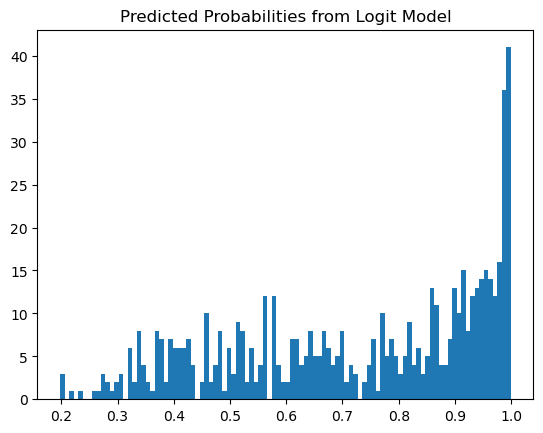

In [21]:
# Histogram of Fitted Values
plt.hist(RecylPredLogit,bins=100)
plt.title("Predicted Probabilities from Logit Model")

In [22]:
# Calculate mean of predicted probabilities
RecylPredLogit.mean()

0.7303

In [23]:
# Calculate classification table
RecylLogit.classification_table()

[134.0, 30.0, 140.0, 304.0]


,Summary,Actual,Predicted,Frequency
0,Correct,0,0,134.0
1,Incorrect,0,1,30.0
2,Incorrect,1,0,140.0
3,Correct,1,1,304.0


In [24]:
# Calculate classification table
Bottle_Recycling_Data["BothLaws"] = (Bottle_Recycling_Data["Mandrecylaw"] * Bottle_Recycling_Data["Waterdep"])

In [25]:
# Include interaction of Mandrecylaw and Waterdep
RecylLogit2 = tprstats.model("logit", "Recycler~Income+Midwest+Northeast+West+Them+Me+Green+Goallaw+Planlaw+Mandrecylaw+Nonwaterdep+Waterdep+I(Mandrecylaw*Waterdep)", Bottle_Recycling_Data)
RecylLogit2.summary()

Optimization terminated successfully.
         Current function value: 0.437347
         Iterations 7


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:               Recycler   No. Observations:                  608
Model:                          Logit   Df Residuals:                      594
Method:                           MLE   Df Model:                           13
Date:                Mon, 14 Apr 2025   Pseudo R-squ.:                  0.2498
Time:                        16:20:43   Log-Likelihood:                -265.91
converged:                       True   LL-Null:                       -354.46
Covariance Type:            nonrobust   LLR p-value:                 6.592e-31
=============================================================================================
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept                    -1.1871      0.321     -3.695      0.000      -1.817      -0.557
Income                        0.0947      0.028      3.343      0.001       0.039       0.150
Midwest                       0.4080      0.260      1.572      0.116      -0.101       0.917
Northeast                     2.4445      0.595      4.106      0.000       1.278       3.611
West                       4.257e-05      0.371      0.000      1.000      -0.726       0.726
Them                          0.2237      0.430      0.520      0.603      -0.619       1.066
Me                            1.3988      0.376      3.715      0.000       0.661       2.137
Green                         0.9078      0.239      3.791      0.000       0.438       1.377
Goallaw                      -0.4432      0.584     -0.759      0.448      -1.587       0.701
Planlaw                       0.3221      0.283      1.140      0.254      -0.232       0.876
Mandrecylaw                   1.1095      0.334      3.324      0.001       0.455       1.764
Nonwaterdep                  -0.4166      0.432     -0.964      0.335      -1.264       0.430
Waterdep                      2.3000      0.609      3.779      0.000       1.107       3.493
I(Mandrecylaw * Waterdep)    -1.8538      0.965     -1.921      0.055      -3.745       0.038
=============================================================================================
"""

In [26]:
# Calculate marginal effects
RecylLogit2.marginal_effects()

<class 'statsmodels.iolib.summary.Summary'>
"""
        Logit Marginal Effects       
=====================================
Dep. Variable:               Recycler
Method:                          dydx
At:                           overall
=============================================================================================
                               dy/dx    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Income                        0.0137      0.004      3.474      0.001       0.006       0.021
Midwest                       0.0591      0.037      1.585      0.113      -0.014       0.132
Northeast                     0.3539      0.082      4.292      0.000       0.192       0.515
West                       6.162e-06      0.054      0.000      1.000      -0.105       0.105
Them                          0.0324      0.062      0.521      0.602      -0.089       0.154
Me                            0.2025      0.053      3.853      0.000       0.100       0.306
Green                         0.1314      0.033      3.997      0.000       0.067       0.196
Goallaw                      -0.0642      0.084     -0.760      0.447      -0.230       0.101
Planlaw                       0.0466      0.041      1.146      0.252      -0.033       0.126
Mandrecylaw                   0.1606      0.046      3.463      0.001       0.070       0.252
Nonwaterdep                  -0.0603      0.062     -0.966      0.334      -0.183       0.062
Waterdep                      0.3330      0.085      3.931      0.000       0.167       0.499
I(Mandrecylaw * Waterdep)    -0.2684      0.138     -1.943      0.052      -0.539       0.002
=============================================================================================
"""

In [27]:
# Using probit
RecylProbit = tprstats.model("probit", "Recycler~Income+Midwest+Northeast+West+Them+Me+Green+C(Recylaw)+C(Deposlaw)", Bottle_Recycling_Data)
RecylProbit.summary()

Optimization terminated successfully.
         Current function value: 0.443663
         Iterations 7


<class 'statsmodels.iolib.summary.Summary'>
"""
                          Probit Regression Results                           
==============================================================================
Dep. Variable:               Recycler   No. Observations:                  608
Model:                         Probit   Df Residuals:                      595
Method:                           MLE   Df Model:                           12
Date:                Mon, 14 Apr 2025   Pseudo R-squ.:                  0.2390
Time:                        16:20:43   Log-Likelihood:                -269.75
converged:                       True   LL-Null:                       -354.46
Covariance Type:            nonrobust   LLR p-value:                 6.244e-30
====================================================================================
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept           -0.6635      0.188     -3.528      0.000      -1.032      -0.295
Income               0.0509      0.016      3.189      0.001       0.020       0.082
Midwest              0.2148      0.155      1.389      0.165      -0.088       0.518
Northeast            1.1658      0.299      3.894      0.000       0.579       1.753
West                 0.1198      0.214      0.559      0.576      -0.300       0.540
Them                 0.1460      0.241      0.605      0.545      -0.327       0.619
Me                   0.7992      0.201      3.973      0.000       0.405       1.193
Green                0.5071      0.137      3.693      0.000       0.238       0.776
C(Recylaw)[T.1]     -0.2272      0.342     -0.665      0.506      -0.897       0.442
C(Recylaw)[T.2]      0.2436      0.170      1.435      0.151      -0.089       0.576
C(Recylaw)[T.3]      0.5753      0.192      2.996      0.003       0.199       0.952
C(Deposlaw)[T.1]    -0.1788      0.244     -0.733      0.463      -0.657       0.299
C(Deposlaw)[T.2]     0.9165      0.280      3.270      0.001       0.367       1.466
====================================================================================
"""

In [28]:
# Probit marginal effects
RecylProbit.marginal_effects()

<class 'statsmodels.iolib.summary.Summary'>
"""
       Probit Marginal Effects       
=====================================
Dep. Variable:               Recycler
Method:                          dydx
At:                           overall
====================================================================================
                      dy/dx    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
Income               0.0129      0.004      3.268      0.001       0.005       0.021
Midwest              0.0543      0.039      1.396      0.163      -0.022       0.131
Northeast            0.2949      0.074      3.999      0.000       0.150       0.439
West                 0.0303      0.054      0.560      0.576      -0.076       0.136
Them                 0.0369      0.061      0.606      0.545      -0.083       0.156
Me                   0.2022      0.049      4.123      0.000       0.106       0.298
Green                0.1283      0.034      3.821      0.000       0.062       0.194
C(Recylaw)[T.1]     -0.0575      0.086     -0.666      0.506      -0.227       0.112
C(Recylaw)[T.2]      0.0616      0.043      1.445      0.148      -0.022       0.145
C(Recylaw)[T.3]      0.1455      0.047      3.068      0.002       0.053       0.239
C(Deposlaw)[T.1]    -0.0452      0.062     -0.734      0.463      -0.166       0.076
C(Deposlaw)[T.2]     0.2319      0.070      3.329      0.001       0.095       0.368
====================================================================================
"""

### Analyze Solar Sales

In [29]:
# Import Solar_Data.xlsx
Solar_Data = pandas.read_excel("Solar_Data.xlsx")

In [30]:
# Solar sales linear probability model
LPMsolar = tprstats.model("cs", "Sale~AnnualSave+ElecBill+AnnualCost+DrivesHybrid+NearbySolar+HomeValue", Solar_Data)
LPMsolar.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   Sale   R-squared:                       0.105
Model:                            OLS   Adj. R-squared:                  0.102
No. Observations:                1500   F-statistic:                     8.524
Covariance Type:                  HC1   Prob (F-statistic):           3.99e-09
================================================================================
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept       -0.1818      0.134     -1.356      0.175      -0.445       0.081
AnnualSave       0.0855      0.060      1.417      0.157      -0.033       0.204
ElecBill         0.0109      0.048      0.227      0.821      -0.083       0.105
AnnualCost      -0.1020      0.037     -2.771      0.006      -0.174      -0.030
DrivesHybrid     0.0595      0.029      2.041      0.041       0.002       0.117
NearbySolar      0.1075      0.029      3.676      0.000       0.050       0.165
HomeValue        0.0004      0.000      1.930      0.054   -7.11e-06       0.001
================================================================================

Notes:
[1] Standard Errors are heteroscedasticity robust (HC1)
[2] The condition number is large, 1.56e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [31]:
# Test hypothesis that coefficients of AnnualSave and ElecBill are both equal to zero
LPMsolar.wald_test("AnnualSave=0, ElecBill=0")

p-value:  0.0


In [32]:
# Solar LPM without ElecBill
LPMsolar = tprstats.model("cs", "Sale~AnnualSave+AnnualCost+DrivesHybrid+NearbySolar+HomeValue", Solar_Data)
LPMsolar.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   Sale   R-squared:                       0.105
Model:                            OLS   Adj. R-squared:                  0.102
No. Observations:                1500   F-statistic:                     10.15
Covariance Type:                  HC1   Prob (F-statistic):           1.42e-09
================================================================================
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept       -0.1797      0.133     -1.346      0.178      -0.441       0.082
AnnualSave       0.0999      0.022      4.544      0.000       0.057       0.143
AnnualCost      -0.1023      0.037     -2.771      0.006      -0.175      -0.030
DrivesHybrid     0.0597      0.029      2.058      0.040       0.003       0.117
NearbySolar      0.1074      0.029      3.674      0.000       0.050       0.165
HomeValue        0.0004      0.000      1.925      0.054   -8.36e-06       0.001
================================================================================

Notes:
[1] Standard Errors are heteroscedasticity robust (HC1)
[2] The condition number is large, 1.55e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

Text(0.5, 1.0, 'Histogram of Fitted Values from Linear Probability Model')

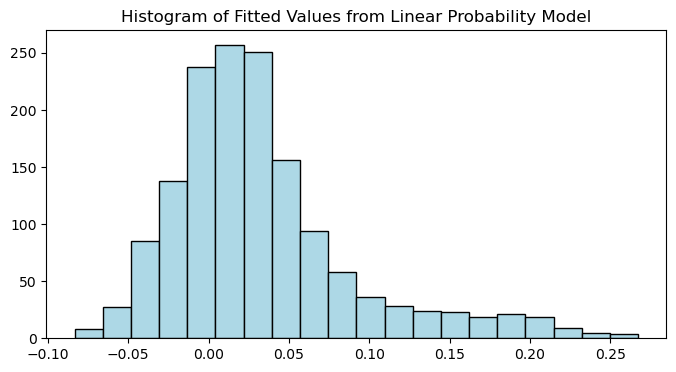

In [33]:
# Calculate fitted values and do a histogram
LPMfit = LPMsolar.predict()
plt.figure(figsize=(8, 4))
plt.hist(LPMfit, bins=20, edgecolor='black', color='lightblue')
plt.title("Histogram of Fitted Values from Linear Probability Model")

In [34]:
# Now estimate solar sales model using logit
logitsolar = tprstats.model("logit", "Sale~AnnualSave+ElecBill+AnnualCost+DrivesHybrid+NearbySolar+HomeValue", Solar_Data)
logitsolar.summary()

Optimization terminated successfully.
         Current function value: 0.102924
         Iterations 9


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:                   Sale   No. Observations:                 1500
Model:                          Logit   Df Residuals:                     1493
Method:                           MLE   Df Model:                            6
Date:                Mon, 14 Apr 2025   Pseudo R-squ.:                  0.2847
Time:                        16:20:44   Log-Likelihood:                -154.39
converged:                       True   LL-Null:                       -215.84
Covariance Type:            nonrobust   LLR p-value:                 3.993e-24
================================================================================
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept      -12.7257      4.844     -2.627      0.009     -22.219      -3.233
AnnualSave       4.0446      1.814      2.229      0.026       0.489       7.600
ElecBill        -0.0849      1.220     -0.070      0.945      -2.477       2.307
AnnualCost      -4.1045      1.478     -2.777      0.005      -7.001      -1.208
DrivesHybrid     0.9631      0.414      2.327      0.020       0.152       1.774
NearbySolar      1.9434      0.398      4.881      0.000       1.163       2.724
HomeValue        0.0178      0.008      2.187      0.029       0.002       0.034
================================================================================
"""

In [35]:
# Logit without ElecBill
logitsolar = tprstats.model("logit", "Sale~AnnualSave+AnnualCost+DrivesHybrid+NearbySolar+HomeValue", Solar_Data)
logitsolar.summary()

Optimization terminated successfully.
         Current function value: 0.102926
         Iterations 9


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:                   Sale   No. Observations:                 1500
Model:                          Logit   Df Residuals:                     1494
Method:                           MLE   Df Model:                            5
Date:                Mon, 14 Apr 2025   Pseudo R-squ.:                  0.2847
Time:                        16:20:44   Log-Likelihood:                -154.39
converged:                       True   LL-Null:                       -215.84
Covariance Type:            nonrobust   LLR p-value:                 7.619e-25
================================================================================
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept      -12.7445      4.837     -2.635      0.008     -22.224      -3.265
AnnualSave       3.9268      0.649      6.048      0.000       2.654       5.199
AnnualCost      -4.0989      1.475     -2.778      0.005      -6.990      -1.207
DrivesHybrid     0.9644      0.413      2.333      0.020       0.154       1.775
NearbySolar      1.9421      0.398      4.884      0.000       1.163       2.722
HomeValue        0.0178      0.008      2.192      0.028       0.002       0.034
================================================================================
"""

In [36]:
Solar_Data['Sale'].mean()

0.0327

In [37]:
# Calculate average marginal effects
logitsolar.marginal_effects()

<class 'statsmodels.iolib.summary.Summary'>
"""
        Logit Marginal Effects       
=====================================
Dep. Variable:                   Sale
Method:                          dydx
At:                           overall
================================================================================
                  dy/dx    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
AnnualSave       0.1013      0.018      5.535      0.000       0.065       0.137
AnnualCost      -0.1057      0.039     -2.721      0.007      -0.182      -0.030
DrivesHybrid     0.0249      0.011      2.312      0.021       0.004       0.046
NearbySolar      0.0501      0.011      4.611      0.000       0.029       0.071
HomeValue        0.0005      0.000      2.161      0.031    4.27e-05       0.001
================================================================================
"""

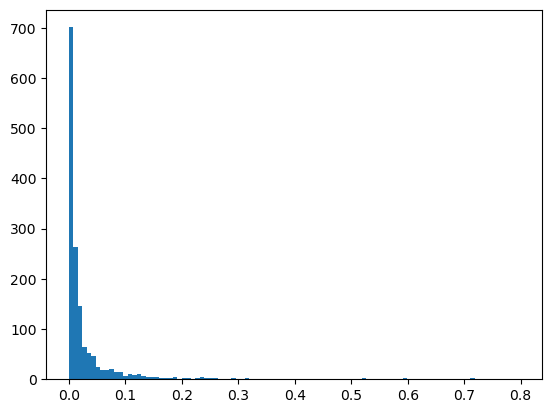

In [38]:
# Calculate fitted values and plot a histogram
logitfit = logitsolar.predict()
plt.hist(logitfit, bins=100)
plt.show()

In [39]:
# View classification table with default cutoff probability
logitsolar.classification_table()

[1176.0, 275.0, 6.0, 43.0]


,Summary,Actual,Predicted,Frequency
0,Correct,0,0,1176.0
1,Incorrect,0,1,275.0
2,Incorrect,1,0,6.0
3,Correct,1,1,43.0


View classification table with user-specified cutoff probability.

#### Sensitivity Analysis
We left ElecBill out of the model. Let's investigate if this makes a material difference in our results.

In [40]:
logitsolar2 = tprstats.model("logit", "Sale~AnnualSave+ElecBill+AnnualCost+DrivesHybrid+NearbySolar+HomeValue", Solar_Data)
logitsolar2.classification_table()

Optimization terminated successfully.
         Current function value: 0.102924
         Iterations 9
[1175.0, 276.0, 6.0, 43.0]


,Summary,Actual,Predicted,Frequency
0,Correct,0,0,1175.0
1,Incorrect,0,1,276.0
2,Incorrect,1,0,6.0
3,Correct,1,1,43.0


In [41]:
#  p_cutoff = 0.1
logitsolar.classification_table(0.1)

[1368.0, 83.0, 22.0, 27.0]


,Summary,Actual,Predicted,Frequency
0,Correct,0,0,1368.0
1,Incorrect,0,1,83.0
2,Incorrect,1,0,22.0
3,Correct,1,1,27.0


In [42]:
#  p_cutoff = 0.15
logitsolar.classification_table(0.15)

[1405.0, 46.0, 28.0, 21.0]


,Summary,Actual,Predicted,Frequency
0,Correct,0,0,1405.0
1,Incorrect,0,1,46.0
2,Incorrect,1,0,28.0
3,Correct,1,1,21.0


We can do prediction for homes not in our sample. For example, we can predict purchase probabilities for three homes with the following characteristics.

In [43]:
Xnew = pandas.DataFrame(
    {
        "AnnualSave": [2.5, 1.9, 2.3],
        "AnnualCost": [1.8, 1.5, 1.7],
        "DrivesHybrid": [1, 0, 0],
        "NearbySolar": [0, 1, 0],
        "HomeValue": [550, 675, 495],
    }
)

In [44]:
# Calculated predicted probability of purchase
logitsolar.predict(Xnew)

0    0.613822
1    0.927109
2    0.135068
dtype: float64

Prediction can also be done from a spreadsheet with information about new prospects. Predict values from the Solar_New_Prospects data and name result PredNew.  

In [45]:
Solar_New_Prospects = pandas.read_excel("Solar_New_Prospects.xlsx")
PredNew = logitsolar.predict(Solar_New_Prospects)

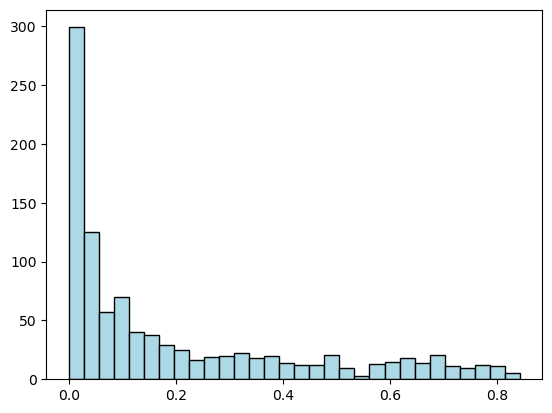

In [46]:
# The semicolon following the command prevents numbers from being displayed.
plt.hist(PredNew, bins=30, edgecolor='black', color='lightblue');

Rank new prospects in order of predicted probability of purchase and write to a csv file. 

In [47]:
RankNew = logitsolar.predict_and_rank(Solar_New_Prospects)
RankNew = RankNew.drop(columns=['Intercept'])
RankNew.to_csv("Ranked_New_Prospects.csv")

Text(0, 0.5, 'New Prospect Predicted Purchase Probabilities')

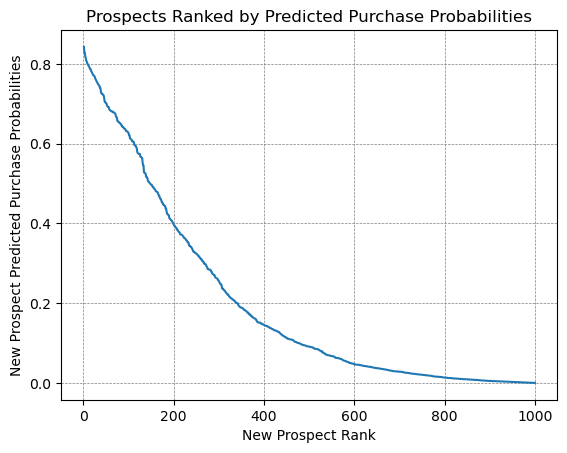

In [48]:
plt.plot(RankNew["ProspectRank"], RankNew["PredictionNew"])
plt.grid(color='gray', linestyle='--', linewidth=0.5)
plt.title('Prospects Ranked by Predicted Purchase Probabilities')
plt.xlabel('New Prospect Rank')
plt.ylabel('New Prospect Predicted Purchase Probabilities')

The next commands show how to estimate with probit.

In [49]:
# probit
probitsolar = tprstats.model("probit", "Sale~AnnualSave+AnnualCost+DrivesHybrid+NearbySolar+HomeValue", Solar_Data)
probitsolar.summary()

Optimization terminated successfully.
         Current function value: 0.100579
         Iterations 9


<class 'statsmodels.iolib.summary.Summary'>
"""
                          Probit Regression Results                           
==============================================================================
Dep. Variable:                   Sale   No. Observations:                 1500
Model:                         Probit   Df Residuals:                     1494
Method:                           MLE   Df Model:                            5
Date:                Mon, 14 Apr 2025   Pseudo R-squ.:                  0.3010
Time:                        16:20:44   Log-Likelihood:                -150.87
converged:                       True   LL-Null:                       -215.84
Covariance Type:            nonrobust   LLR p-value:                 2.450e-26
================================================================================
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept       -6.5365      2.307     -2.833      0.005     -11.058      -2.015
AnnualSave       1.9807      0.314      6.310      0.000       1.365       2.596
AnnualCost      -2.1618      0.741     -2.917      0.004      -3.614      -0.709
DrivesHybrid     0.5292      0.205      2.581      0.010       0.127       0.931
NearbySolar      0.9933      0.197      5.044      0.000       0.607       1.379
HomeValue        0.0093      0.004      2.387      0.017       0.002       0.017
================================================================================
"""

In [50]:
# Calculate probit marginal effects
probitsolar.marginal_effects()

<class 'statsmodels.iolib.summary.Summary'>
"""
       Probit Marginal Effects       
=====================================
Dep. Variable:                   Sale
Method:                          dydx
At:                           overall
================================================================================
                  dy/dx    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
AnnualSave       0.1026      0.018      5.784      0.000       0.068       0.137
AnnualCost      -0.1120      0.039     -2.866      0.004      -0.189      -0.035
DrivesHybrid     0.0274      0.011      2.556      0.011       0.006       0.048
NearbySolar      0.0514      0.011      4.784      0.000       0.030       0.073
HomeValue        0.0005      0.000      2.356      0.018    8.07e-05       0.001
================================================================================
"""